# EM field-line and isosurface post-processing (gmsh lane)

The standard post-processing recipes for `GmshPostExport` output using the
`radia-mcp` gmsh verbs, demonstrated on two analytic-field cases so every
picture has a quantitative check next to it.

**Field-line tool selection** (decreasing exactness -- always prefer the
highest one that applies):

| situation | tool | property |
|---|---|---|
| 2D / axisymmetric with a potential | `flux_lines` on $A_z$ or $\psi = r A_\theta$ | exact lines, EQUAL FLUX between adjacent lines |
| plane slice of a 3D field | `streamlines_2d` | evenly spaced (Jobard-Lefer); exact on symmetry planes ($B\cdot n = 0$) |
| true 3D lines | `streamlines` | curvature-adaptive RK4, closed-loop detection, termination reasons |

Isosurfaces: `flux_lines` level stacks with `recur_level>0` (adaptive
extraction on order-2 data) + smooth shading (render default) + clip.
All spatial renders are axis equal by policy (gmsh default 1:1:1).

* **Case A** -- circular coil (axisymmetric): $\psi$ contours are the exact
  field lines; the evenly spaced tracer is cross-checked against $\psi$
  conservation.
* **Case B** -- opposed permanent-magnet gap (3D): mid-plane streamlines,
  gap profile, nested $|B|$ isosurfaces with cut-away.


In [1]:
import json
import math
import platform
from datetime import datetime, timezone
from pathlib import Path

import radia as rad
from IPython.display import Image, display
from ngsolve import CF, InnerProduct, Mesh, TaskManager, sqrt, x, y, z
from netgen.occ import Box, OCCGeometry, Pnt, Sphere

from radia.coil_builder import CoilBuilder
from radia.gmsh_post_export import GmshPostExport
from radia_mcp.gmsh.post_process import (
    cut_plane_extract, flux_lines, line_profile, math_eval, probe_field,
    streamlines_2d, view_min_max,
)
from radia_mcp.gmsh.render import export_animation, render_png

OUT = Path("output")
OUT.mkdir(exist_ok=True)
MU0 = 4e-7 * math.pi
results = {}

def show(png_path):
    display(Image(filename=str(png_path)))


## Case A -- circular coil: exact equal-flux field lines

A single 1000 A-turn loop of radius $a = 50$ mm (Biot-Savart source via
`CoilBuilder`).  The flux function $\psi = r\,A_\theta$ is exported on a
thin slab through the axis; its equally spaced contours are the exact
field lines of the loop, with equal flux $\Delta\psi$ between neighbors.


In [2]:
rad.UtiDelAll()
a_loop, current = 0.05, 1000.0
builder = CoilBuilder(current=current)
builder.set_start([a_loop, 0.0, 0.0])
builder.set_cross_section(0.004, 0.004)
builder.add_arc(a_loop, 360.0)
coil = rad.ObjCnt(builder.to_radia(arc_max_segment_length=0.004))

B0 = rad.Fld(coil, 'b', [0.0, 0.0, 0.0])
B0_analytic = MU0 * current / (2 * a_loop)
rel = abs(B0[2] - B0_analytic) / B0_analytic
print(f"B(0,0,0) = {B0[2]:.6e} T   analytic mu0*I/(2a) = {B0_analytic:.6e} T"
      f"   rel err = {rel:.2e}")
results["case_a"] = {"B0_T": B0[2], "B0_analytic_T": B0_analytic,
                     "B0_rel_err": rel}
assert rel < 1e-3


B(0,0,0) = 1.256301e-02 T   analytic mu0*I/(2a) = 1.256637e-02 T   rel err = 2.68e-04


In [3]:
# thin slab through the coil axis, psi and B as NodeData
A_cf = rad.RadiaField(coil, 'a')
B_cf = rad.RadiaField(coil, 'b')
psi_cf = x * A_cf[1]  # on the y=0 plane: r = x, A_theta = A_y

with TaskManager():
    slab = Mesh(OCCGeometry(
        Box(Pnt(0.004, -0.003, -0.055),
            Pnt(0.120, 0.003, 0.055))).GenerateMesh(maxh=0.0055))
    post = GmshPostExport(slab)
    post.add_field("psi", psi_cf)
    post.add_vector_field("B", B_cf)
    post.write(str(OUT / "coil_slab.msh"))


GMSH export: output\coil_slab.msh
  2866 elements, 1038 nodes, 2 fields
  Materials: default(2866)


flux lines: 14 levels, 1378 segments


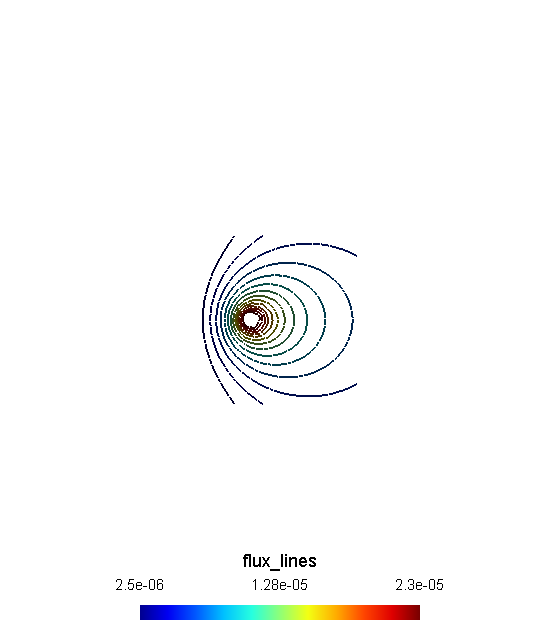

In [4]:
# exact flux lines: cut the psi view at y=0, contour between
# psi(r=12mm) and psi(r=46mm) -- equal Delta-psi = equal flux per gap
cut = cut_plane_extract(OUT / "coil_slab.msh", [0, 1, 0], 0.0,
                        view="psi", out_file=OUT / "psi_section.pos")
assert cut["ok"], cut

def psi_at(r_pos):
    A = rad.Fld(coil, 'a', [r_pos, 0.0, 0.0])
    return r_pos * A[1]

lo, hi = psi_at(0.012), psi_at(0.046)
levels = [lo + (hi - lo) * (k + 1) / 15 for k in range(14)]
fl = flux_lines(OUT / "psi_section.pos", levels=levels,
                out_file=OUT / "coil_fluxlines.pos")
assert fl["ok"], fl
print("flux lines:", len(fl["levels"]), "levels,",
      fl["pieces"].get("SL"), "segments")

r = render_png(OUT / "coil_fluxlines.pos", OUT / "coil_fluxlines.png",
               width=760, height=640, rotation=[-90, 0, 0],
               options={"View.LineWidth": 2.0, "General.SmallAxes": 0})
assert r.get("ok") and not r.get("blank_check", {}).get("looks_blank"), r
show(OUT / "coil_fluxlines.png")


20 lines (3 closed), 830 integration steps
psi drift along the longest traced line: 6.32e-03 (rel)


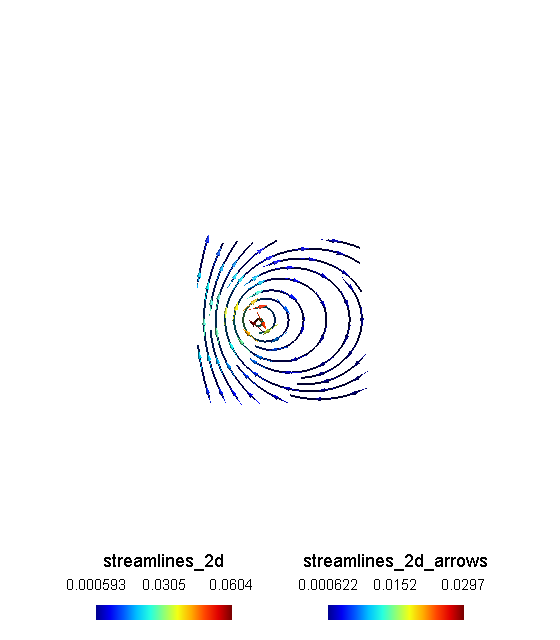

In [5]:
# evenly spaced streamlines on the same plane + psi cross-check
sl = streamlines_2d(OUT / "coil_slab.msh", [0.012, 0.0, -0.05],
                    [0.115, 0.0, -0.05], [0.012, 0.0, 0.05],
                    view="B", d_sep=0.0075, arrows_every=12,
                    return_points=True,
                    out_file=OUT / "coil_stream2d.pos")
assert sl["ok"], sl
print(f"{sl['n_lines']} lines ({sl['n_closed']} closed),",
      f"{sl['steps_used']} integration steps")

# a traced field line must conserve psi (exactness cross-check)
line = max(sl["lines"], key=lambda L: L["n_points"])
psis = [p[0] * rad.Fld(coil, 'a', p)[1] for p in line["points"]]
span = max(abs(v) for v in psis)
drift = (max(psis) - min(psis)) / span
print(f"psi drift along the longest traced line: {drift:.2e} (rel)")
results["case_a"].update({
    "n_stream_lines": sl["n_lines"], "psi_rel_drift": drift})
assert drift < 0.02

r = render_png(OUT / "coil_stream2d.pos", OUT / "coil_stream2d.png",
               width=760, height=640, rotation=[-90, 0, 0],
               options={"View.LineWidth": 2.0, "General.SmallAxes": 0})
assert r.get("ok") and not r.get("blank_check", {}).get("looks_blank"), r
show(OUT / "coil_stream2d.png")


## Case B -- opposed-PM gap: the 3D post battery

Two NdFeB-class blocks ($B_r = 1.2$ T, magnetized $+y$) face each other
across a 20 mm gap.  The $z = 0$ mid-plane is a symmetry plane
($B_z = 0$ there), so the evenly spaced streamlines on it are exact
field lines; the gap profile and the nested $|B|$ isosurfaces complete
the standard battery.


In [6]:
rad.UtiDelAll()
M = 954930.0  # A/m  (Br = 1.2 T)
pm_top = rad.ObjRecMag([0.0, 0.020, 0.0], [0.04, 0.02, 0.04], [0, M, 0])
pm_bot = rad.ObjRecMag([0.0, -0.020, 0.0], [0.04, 0.02, 0.04], [0, M, 0])
magnet = rad.ObjCnt([pm_top, pm_bot])

Bg = rad.Fld(magnet, 'b', [0.0, 0.0, 0.0])
Bsym = rad.Fld(magnet, 'b', [0.012, 0.004, 0.0])
print(f"gap center B = ({Bg[0]:.4f}, {Bg[1]:.4f}, {Bg[2]:.4f}) T")
print(f"mid-plane symmetry check: Bz(0.012, 0.004, 0) = {Bsym[2]:.2e} T")
results["case_b"] = {"B_gap_T": Bg[1]}
assert abs(Bsym[2]) < 1e-12


gap center B = (0.0000, 0.4695, 0.0000) T
mid-plane symmetry check: Bz(0.012, 0.004, 0) = -2.51e-17 T


GMSH export: output\pm_slab.msh
  4985 elements, 1765 nodes, 1 fields
  Materials: default(4985)


42 lines, 2 closed


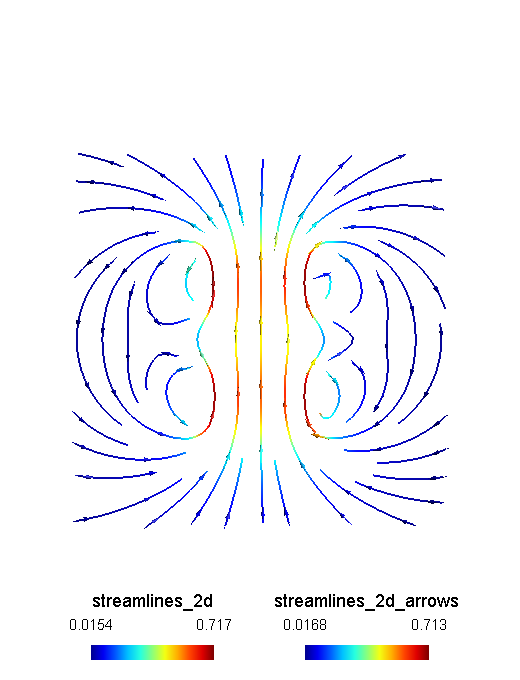

In [7]:
# mid-plane slab export + evenly spaced streamlines (exact here)
B2_cf = rad.RadiaField(magnet, 'b')
with TaskManager():
    slab_b = Mesh(OCCGeometry(
        Box(Pnt(-0.065, -0.065, -0.004),
            Pnt(0.065, 0.065, 0.004))).GenerateMesh(maxh=0.005))
    post = GmshPostExport(slab_b)
    post.add_vector_field("B", B2_cf)
    post.write(str(OUT / "pm_slab.msh"))

sl_b = streamlines_2d(OUT / "pm_slab.msh", [-0.062, -0.062, 0.0],
                      [0.062, -0.062, 0.0], [-0.062, 0.062, 0.0],
                      view="B", d_sep=0.0085, arrows_every=10,
                      out_file=OUT / "pm_stream2d.pos")
assert sl_b["ok"], sl_b
print(f"{sl_b['n_lines']} lines, {sl_b['n_closed']} closed")
results["case_b"]["n_stream_lines"] = sl_b["n_lines"]

r = render_png(OUT / "pm_stream2d.pos", OUT / "pm_stream2d.png",
               width=720, height=680, rotation=[0, 0, 0],
               options={"View.LineWidth": 2.0, "General.SmallAxes": 0})
assert r.get("ok") and not r.get("blank_check", {}).get("looks_blank"), r
show(OUT / "pm_stream2d.png")


By on gap center line: 0.2216 .. 0.4666 T (spread 52.5%)


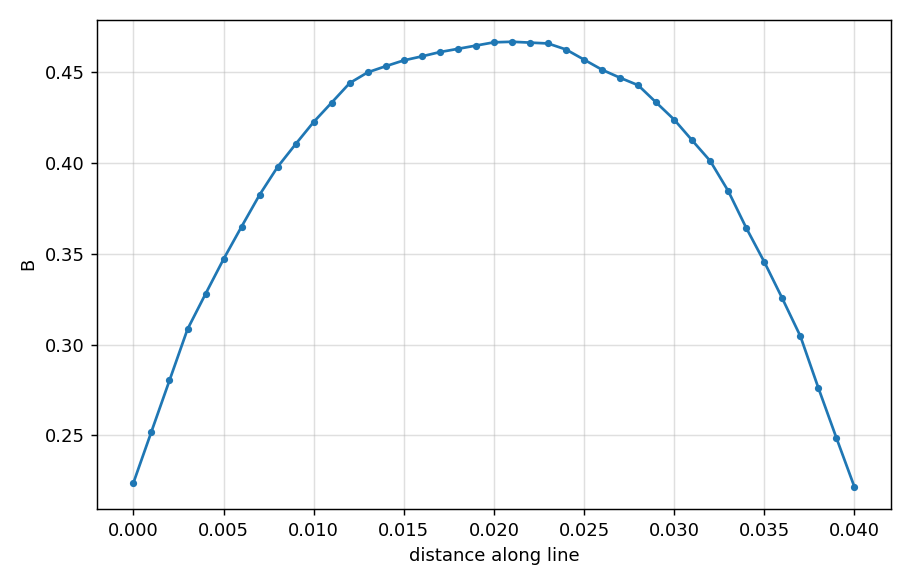

|B| max on mid-plane: 0.8483 T at [0.0198, 0.0256, 0.004]


In [8]:
# gap uniformity: |B_y| along the gap center line + extrema location
prof = line_profile(OUT / "pm_slab.msh", [-0.02, 0.0, 0.0],
                    [0.02, 0.0, 0.0], n=41, view="B",
                    plot_png=OUT / "gap_profile.png")
assert prof["ok"], prof
by = [p["values"][1] if p.get("values") else p["steps"][0][1]
      for p in prof["views"][0]["points"]]
uniformity = (max(by) - min(by)) / abs(by[len(by) // 2])
print(f"By on gap center line: {min(by):.4f} .. {max(by):.4f} T "
      f"(spread {uniformity:.1%})")
results["case_b"]["gap_By_spread_rel"] = uniformity
show(OUT / "gap_profile.png")

mag = math_eval(OUT / "pm_slab.msh", ["Sqrt(v0^2+v1^2+v2^2)"],
                view="B", result_name="magB",
                out_file=OUT / "pm_magB.pos")
assert mag["ok"], mag
mm = view_min_max(OUT / "pm_magB.pos")
print("|B| max on mid-plane:", round(mm["max"]["values"][0], 4), "T at",
      [round(v, 4) for v in mm["max"]["point"]])
results["case_b"]["midplane_Bmax_T"] = mm["max"]["values"][0]


GMSH export: output\pm_Bmag.msh
  5306 elements, 8571 nodes, 1 fields
  Materials: default(5306)


iso levels |B| [T]: [0.0465, 0.1389, 0.3424]


triangles: {'ST': 119474, 'SQ': 50643}


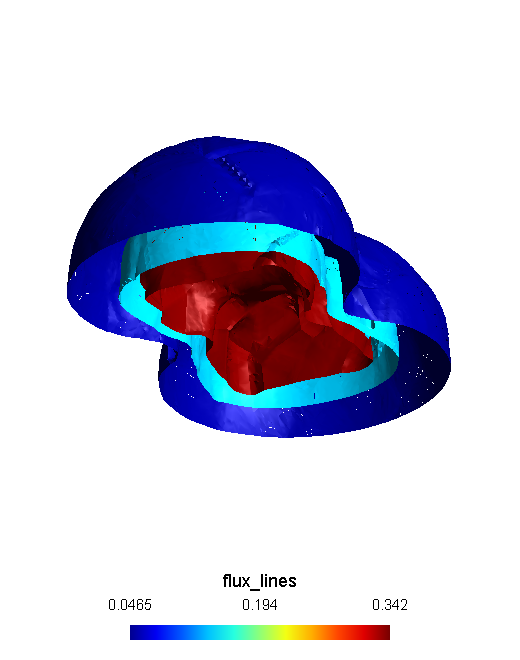

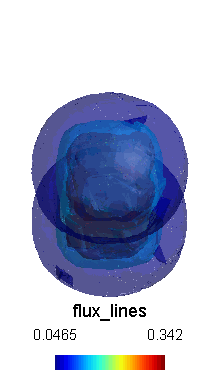

In [9]:
# nested |B| isosurfaces: order-2 sphere domain, adaptive extraction,
# opaque CLIP render (the preferred nesting recipe) + orbit GIF
with TaskManager():
    dome = Mesh(OCCGeometry(
        Sphere(Pnt(0, 0, 0), 0.085)).GenerateMesh(maxh=0.012))
    dome.Curve(2)
    post = GmshPostExport(dome)
    post.add_field("Bmag", sqrt(1e-30 + InnerProduct(B2_cf, B2_cf)))
    post.write(str(OUT / "pm_Bmag.msh"))

pr = probe_field(OUT / "pm_Bmag.msh",
                 [[0.0, 0.035, 0.0], [0.0, 0.05, 0.0], [0.0, 0.07, 0.0]])
levels = sorted(p["values"][0] if p.get("values") else p["steps"][0][0]
                for p in pr["views"][0]["points"])
print("iso levels |B| [T]:", [round(v, 4) for v in levels])

iso = flux_lines(OUT / "pm_Bmag.msh", levels=levels, recur_level=3,
                 target_error=1e-5, out_file=OUT / "pm_iso.pos")
assert iso["ok"], iso
print("triangles:", iso["pieces"])
results["case_b"]["iso_levels_T"] = levels

r = render_png(OUT / "pm_iso.pos", OUT / "pm_iso_clip.png",
               width=720, height=660, rotation=[62, 0, 25],
               cut_plane={"enabled": True, "normal": [0, 0, -1],
                          "offset": 0.0},
               options={"General.SmallAxes": 0})
assert r.get("ok") and not r.get("blank_check", {}).get("looks_blank"), r
show(OUT / "pm_iso_clip.png")

orb = export_animation(OUT / "pm_iso.pos", OUT / "pm_iso_orbit.gif",
                       orbit_axis="y", orbit_frames=24, width=420,
                       height=390, rotation=[62, 0, 0],
                       options={"View[0].ColormapAlpha": 0.42,
                                "General.SmallAxes": 0})
assert orb.get("ok"), orb
display(Image(data=open(OUT / "pm_iso_orbit.gif", "rb").read(),
              format="gif"))


### Interactive WebGUI scenes

The gmsh lane above produces the DUMPED figures; the interactive
inspection contract for example notebooks is `ngsolve.webgui.Draw`.


In [10]:
from ngsolve.webgui import Draw

Draw(slab_b, settings={"Objects": {"Wireframe": False}})


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fals…

BaseWebGuiScene

In [11]:
Draw(B2_cf, slab_b, name="B", vectors={"grid_size": 40},
     autoscale=True, clipping={"z": -1, "dist": 0.0})


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

BaseWebGuiScene

## Summary

Key quantities are embedded in this executed notebook. Checked numerical
evidence lives under `validation_test/gmsh_post/`; heavy artifacts (`.msh`,
`.pos`, PNG/GIF) live in `output/` and are regenerated by re-running the
notebook.


In [12]:
import ngsolve

summary = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(
        timespec="seconds").replace("+00:00", "Z"),
    "radia_version": getattr(rad, "__version__", "unknown"),
    "ngsolve_version": ngsolve.__version__,
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "results": results,
}
print(json.dumps(summary["results"], indent=1))
rad.UtiDelAll()


{
 "case_a": {
  "B0_T": 0.012563006222245683,
  "B0_analytic_T": 0.012566370614359171,
  "B0_rel_err": 0.00026772981768050243,
  "n_stream_lines": 20,
  "psi_rel_drift": 0.006322983935574693
 },
 "case_b": {
  "B_gap_T": 0.469465357394112,
  "n_stream_lines": 42,
  "gap_By_spread_rel": 0.5253237554081861,
  "midplane_Bmax_T": 0.8483270255713358,
  "iso_levels_T": [
   0.04651171353646124,
   0.1389182111610222,
   0.342430641553493
  ]
 }
}
